# **Task 1: Binary Hypothesis Testing under the Bayes Criterion (2-class problem)**

# Common Utility Functions

In [ ]:
import numpy as np
import pandas as pd

def stratified_split(raw_cat, seed=1):
    rng = np.random.RandomState(seed)
    tr, te = [], []
    for c in np.unique(raw_cat):
        idx = np.where(raw_cat == c)[0]
        rng.shuffle(idx)
        cut = len(idx) // 2
        tr.append(idx[:cut]); te.append(idx[cut:])
    return np.concatenate(tr), np.concatenate(te)

def estimate_bernoulli(X, y, classes):
    Xb = (X > 0).astype(np.int64)
    P_prior = np.array([np.mean(y == c) for c in classes])
    P_xi_h  = np.zeros((len(classes), Xb.shape[1]))
    for j, c in enumerate(classes):
        mask = (y == c); Nj = mask.sum()
        Nij  = Xb[mask].sum(axis=0)
        P_xi_h[j] = (Nij + 1) / (Nj + 2)
    return P_prior, P_xi_h

def estimate_multinomial(X, y, classes, V_features):
    P_prior = np.array([np.mean(y == c) for c in classes])
    P_xi_h  = np.zeros((len(classes), X.shape[1]))
    for j, c in enumerate(classes):
        mask = (y == c)
        tfij = X[mask].sum(axis=0); Nj = X[mask].sum()
        P_xi_h[j] = (tfij + 1) / (Nj + V_features)
    return P_prior, P_xi_h

def loglik_bernoulli(X, P):
    Xb = (X > 0).astype(np.int64)
    return Xb @ np.log(P).T + (1 - Xb) @ np.log(1 - P).T

def loglik_multinomial(X, P):
    return X @ np.log(P).T

def metrics_for_decisions(decide_h1, y_bin):
    h0 = (y_bin == 0); h1 = (y_bin == 1)
    PF = decide_h1[h0].mean() if h0.any() else 0.0
    PD = decide_h1[h1].mean() if h1.any() else 0.0
    PM = 1.0 - PD
    Pe = h0.mean() * PF + h1.mean() * PM
    return PF, PD, PM, Pe

def roc_one_vs_rest(score, y_true, target_cls, gammas):
    """ Decide 'class k' if score > gamma. """
    y_bin = (y_true == target_cls).astype(int)
    PFs, PDs = [], []
    for g in gammas:
        d = (score > g).astype(int)
        PFs.append(d[y_bin == 0].mean() if (y_bin == 0).any() else 0.0)
        PDs.append(d[y_bin == 1].mean() if (y_bin == 1).any() else 0.0)
    PFs, PDs = np.array(PFs), np.array(PDs)
    order = np.argsort(PFs)
    auc = np.trapezoid(PDs[order], PFs[order])
    return PFs, PDs, auc

# gamma grid for the one-vs-rest score (log-domain margin)
GAMMA_GRID_MULTICLASS = np.concatenate([
    [-1e3],                                         # corner: always decide H_k
    np.linspace(-50.0,   0.0, 50, endpoint=False),
    np.linspace(  0.0,  10.0, 50, endpoint=False),
    np.linspace( 10.0, 100.0, 51),                  # tail up to 100
    [1e3],                                          # corner: never decide H_k
])


# **Running for Task 1**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "SeeClickFix_AlbanyCounty_February_2018.csv"   #change the path as necesaary
OUT_FIGS = "figures"
OUT_TABS = "tables"
os.makedirs(OUT_FIGS, exist_ok=True);
os.makedirs(OUT_TABS, exist_ok=True);

TASK1_PREFIX = "task1_"

# -----------------------------------------------------------------
# Load data and build the two macro-classes
# -----------------------------------------------------------------
df = pd.read_csv(CSV_PATH)
raw_cat = df["category"].values
X_all   = df.drop(columns=["issue_id", "category"]).values.astype(np.int64)
V       = X_all.shape[1]

CLASS_A = {"Parking Enforcement", "Code Violations"}
CLASS_B = {"Signs (Missing, Needed, or Damaged)", "Traffic Signal Repairs"}

y_all = np.where(np.isin(raw_cat, list(CLASS_A)), "A",
        np.where(np.isin(raw_cat, list(CLASS_B)), "B", "OTHER"))
assert (y_all != "OTHER").all()

print(f"Loaded: {X_all.shape[0]} requests, {V} features")
print(f"Class A (Parking + Code) ......... {(y_all == 'A').sum()} requests")
print(f"Class B (Signs + Traffic Signal) . {(y_all == 'B').sum()} requests\n")

# -----------------------------------------------------------------
# Stratified 50/50 split (half of each ORIGINAL category to train)
# -----------------------------------------------------------------
tr, te = stratified_split(raw_cat, seed=1)
print(f"Training set: {len(tr)}   Test set: {len(te)}\n")



CLASSES = ["A", "B"]                 # H0 = A, H1 = B



# -----------------------------------------------------------------
# Cost grid: C00 = C11 = 0; vary (C01, C10) widely
# -----------------------------------------------------------------
COST_GRID = [
    # (C00, C01, C10, C11)        comment
    (0,  1,  1, 0),   # uniform / MAP
    (0,  1,  2, 0),   # FA twice as costly as miss
    (0,  1,  5, 0),   # heavy FA penalty
    (0,  1, 10, 0),   # very heavy FA penalty
    (0,  2,  1, 0),   # miss twice as costly as FA
    (0,  5,  1, 0),   # heavy miss penalty
    (0, 10,  1, 0),   # very heavy miss penalty
    (0,  3,  2, 0),   # asymmetric
    (0,  2,  3, 0),   # asymmetric
    (0,  4,  5, 0),   # asymmetric, both costs large
]

def run_task1_binary_hypothesis_test(model):
    if model == "bernoulli":
        Pp, Pxi = estimate_bernoulli(X_all[tr], y_all[tr], CLASSES)
        ll = loglik_bernoulli(X_all[te], Pxi)
    else:
        Pp, Pxi = estimate_multinomial(X_all[tr], y_all[tr], CLASSES, V)
        ll = loglik_multinomial(X_all[te], Pxi)

    log_llr = ll[:, 1] - ll[:, 0]                # log P(x|H1) - log P(x|H0)
    y_bin   = (y_all[te] == "B").astype(int)     # H1 = B
    P0, P1  = Pp[0], Pp[1]

    # ---------- Cost-tuple table ----------
    rows = []
    for (C00, C01, C10, C11) in COST_GRID:
        gamma = (C10 - C00) * P0 / ((C01 - C11) * P1)
        log_gamma = np.log(gamma)
        decide_h1 = (log_llr > log_gamma).astype(int)
        PF, PD, PM, Pe = metrics_for_decisions(decide_h1, y_bin)
        rows.append((C00, C01, C10, C11, gamma, PF, PD, PM, Pe))

    sweep = pd.DataFrame(
        rows, columns=["C00", "C01", "C10", "C11", "gamma",
                       "PF", "PD", "PM", "Pe"]
    )

    # ---------- ROC: sweep gamma from ~0 to ~100 ----------
    GAMMA_GRID = np.concatenate([
        np.linspace(0.0, 1.0, 50, endpoint=False),   # dense near 0
        np.linspace(1.0, 10.0, 50, endpoint=False),  # mid-range
        np.linspace(10.0, 1090000.0, 51),                # tail up to 100
    ])
    roc_PF, roc_PD = [], []
    for g in GAMMA_GRID:
        if g <= 0.0:
            d = np.ones_like(log_llr, dtype=int)     # decide H1 always
        else:
            d = (log_llr > np.log(g)).astype(int)
        roc_PF.append(d[y_bin == 0].mean() if (y_bin == 0).any() else 0.0)
        roc_PD.append(d[y_bin == 1].mean() if (y_bin == 1).any() else 0.0)
    roc_PF = np.array(roc_PF); roc_PD = np.array(roc_PD)
    # add the trivial endpoint (gamma -> infinity: never decide H1)
    roc_PF = np.append(roc_PF, 0.0); roc_PD = np.append(roc_PD, 0.0)
    GAMMAS = np.append(GAMMA_GRID, np.inf)

    order = np.argsort(roc_PF)
    auc = np.trapezoid(roc_PD[order], roc_PF[order])

    return dict(prior=Pp, sweep=sweep,
                roc_gammas=GAMMAS, roc_PF=roc_PF, roc_PD=roc_PD, auc=auc,
                n_train=len(tr), n_test=len(te))

results = {}
for model in ["bernoulli", "multinomial"]:
    r = run_task1_binary_hypothesis_test(model)
    results[model] = r
    out = f"{OUT_TABS}/{TASK1_PREFIX}sweep_classA_vs_classB_{model}.csv"
    r["sweep"].to_csv(out, index=False, float_format="%.4f")
    print(f"\n[{model}]   AUC = {r['auc']:.4f}   "
          f"P0(A) = {r['prior'][0]:.3f}  P1(B) = {r['prior'][1]:.3f}")
    print(r["sweep"].to_string(index=False, float_format="%.3f"))
    print(f"  -> {out}")

print(f"\nROC figure  -> ./{OUT_FIGS}/{TASK1_PREFIX}roc_classA_vs_classB_side_by_side.png")
print(f"Sweep tables-> ./{OUT_TABS}/")

Loaded: 529 requests, 2535 features
Class A (Parking + Code) ......... 295 requests
Class B (Signs + Traffic Signal) . 234 requests

Training set: 264   Test set: 265


[bernoulli]   AUC = 0.9900   P0(A) = 0.557  P1(B) = 0.443
 C00  C01  C10  C11  gamma    PF    PD    PM    Pe
   0    1    1    0  1.256 0.007 0.949 0.051 0.026
   0    1    2    0  2.513 0.007 0.932 0.068 0.034
   0    1    5    0  6.282 0.007 0.915 0.085 0.042
   0    1   10    0 12.564 0.000 0.915 0.085 0.038
   0    2    1    0  0.628 0.007 0.949 0.051 0.026
   0    5    1    0  0.251 0.007 0.966 0.034 0.019
   0   10    1    0  0.126 0.007 0.974 0.026 0.015
   0    3    2    0  0.838 0.007 0.949 0.051 0.026
   0    2    3    0  1.885 0.007 0.932 0.068 0.034
   0    4    5    0  1.571 0.007 0.932 0.068 0.034
  -> tables/task1_sweep_classA_vs_classB_bernoulli.csv

[multinomial]   AUC = 0.9890   P0(A) = 0.557  P1(B) = 0.443
 C00  C01  C10  C11  gamma    PF    PD    PM    Pe
   0    1    1    0  1.256 0.034 0.966 0.034 

# **Plotting**

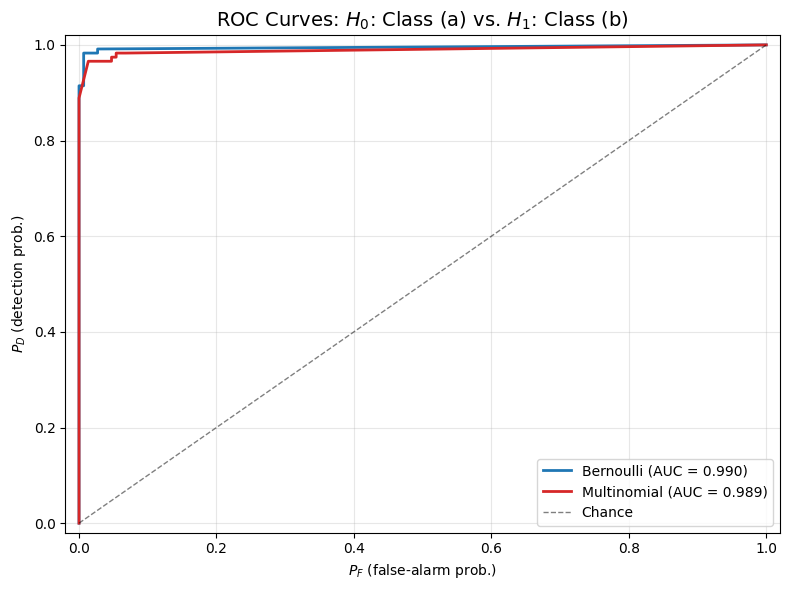

In [ ]:
# -----------------------------------------------------------------
# ROC plot --- show the gamma sweep
# -----------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Create a single subplot
colors = {"bernoulli": "#1f77b4", "multinomial": "#d62728"}

for model in ["bernoulli", "multinomial"]:
    r = results[model]
    ax.plot(r["roc_PF"], r["roc_PD"], lw=2, color=colors[model],
            label=f"{model.capitalize()} (AUC = {r['auc']:.3f})")


ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label="Chance")
ax.set_xlabel(r"$P_F$ (false-alarm prob.)")
ax.set_ylabel(r"$P_D$ (detection prob.)")
ax.set_title("ROC Curves: $H_0$: Class (a) vs. $H_1$: Class (b)", fontsize=14)
ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
ax.legend(loc="lower right", fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_FIGS}/{TASK1_PREFIX}roc_classA_vs_classB_combined.png", dpi=140) # Changed filename to reflect combined plot
plt.show()

# **Task 2: Multiple Hypothesis Testing under the Bayes Criterion (4-class problem)**

This task focuses on performing Multiple Hypothesis Testing under the Bayes Criterion using the SeeClickFix Albany County dataset.


**Outputs:**
*   `figures/roc_multiclass_bernoulli.png`
*   `figures/roc_multiclass_multinomial.png`
*   `figures/confusion_bernoulli.png`
*   `figures/confusion_multinomial.png`
*   `tables/confusion_bernoulli.csv`
*   `tables/confusion_multinomial.csv`
*   `tables/per_class_metrics_bernoulli.csv`
*   `tables/per_class_metrics_multinomial.csv`

# **Path & Directory for Task-2**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "SeeClickFix_AlbanyCounty_February_2018.csv"   # change path as necessary
OUT_FIGS = "figures"
OUT_TABS = "tables"
os.makedirs(OUT_FIGS, exist_ok=True)
os.makedirs(OUT_TABS, exist_ok=True)
TASK2_PREFIX = "task2_"

# **Checking the Dataset**

In [ ]:
# -----------------------------------------------------------------
# Load data
# -----------------------------------------------------------------
df = pd.read_csv(CSV_PATH)
y_all = df["category"].values
X_all = df.drop(columns=["issue_id", "category"]).values.astype(np.int64)
V     = X_all.shape[1]

ALL_CLASSES = [
    "Parking Enforcement",
    "Code Violations",
    "Signs (Missing, Needed, or Damaged)",
    "Traffic Signal Repairs",
]
SHORT = ["Parking", "Code", "Signs", "Traffic"]
M = len(ALL_CLASSES)

print(f"Loaded: {X_all.shape[0]} requests, {V} features")
for c in ALL_CLASSES:
    print(f"  {c:<42s} {(y_all == c).sum():3d} requests")
print()

Loaded: 529 requests, 2535 features
  Parking Enforcement                        139 requests
  Code Violations                            156 requests
  Signs (Missing, Needed, or Damaged)        124 requests
  Traffic Signal Repairs                     110 requests



# **Data Splitting (Task 2)**

In [ ]:
# -----------------------------------------------------------------
#  Stratified 50/50 split (half of each category to training)
#    (Using the 'stratified_split' function defined in a previous cell)
# -----------------------------------------------------------------
tr, te = stratified_split(y_all, seed=2)
print(f"Training set: {len(tr)}   Test set: {len(te)}\n")

Training set: 264   Test set: 265



# **Run Test for TAsk-2**

In [ ]:
# -----------------------------------------------------------------
#  4-class MAP rule and metrics
# -----------------------------------------------------------------
def run_multiclass(model):
    if model == "bernoulli":
        Pp, Pxi = estimate_bernoulli(X_all[tr], y_all[tr], ALL_CLASSES)
        ll = loglik_bernoulli(X_all[te], Pxi)
    else:
        Pp, Pxi = estimate_multinomial(X_all[tr], y_all[tr], ALL_CLASSES, V)
        ll = loglik_multinomial(X_all[te], Pxi)

    log_post = ll + np.log(Pp)                       # MAP rule (eq. 14)
    pred_idx = log_post.argmax(axis=1)
    pred = np.array(ALL_CLASSES)[pred_idx]
    yte  = y_all[te]

    # Confusion matrix (rows = true, cols = predicted)
    C = np.zeros((M, M), dtype=int)
    for t_lbl, p_lbl in zip(yte, pred):
        C[ALL_CLASSES.index(t_lbl), ALL_CLASSES.index(p_lbl)] += 1
    err = (pred != yte).mean()

    # Per-class one-vs-rest (P_D, P_F, P_M)
    per = []
    for k in range(M):
        TP = C[k, k]
        FN = C[k].sum() - TP
        FP = C[:, k].sum() - TP
        TN = C.sum() - TP - FN - FP
        PD = TP / (TP + FN) if (TP + FN) else 0.0
        PF = FP / (FP + TN) if (FP + TN) else 0.0
        PM = 1 - PD
        per.append((ALL_CLASSES[k], PD, PF, PM))

    return dict(prior=Pp, conf=C, err=err, per=per,
                log_post=log_post, y_true=yte,
                n_train=len(tr), n_test=len(te))

# **Results Printing**

In [ ]:
mc_results = {m: run_multiclass(m) for m in ["bernoulli", "multinomial"]}

for m, r in mc_results.items():
    print(f"\n=== Multi-class [{m}] ===  test error = {r['err']:.4f}  "
          f"({(r['err'] * r['n_test']):.0f}/{r['n_test']})")
    cm_df = pd.DataFrame(r['conf'], index=ALL_CLASSES, columns=ALL_CLASSES)
    print(cm_df.to_string())
    cm_df.to_csv(f"{OUT_TABS}/{TASK2_PREFIX}confusion_{m}.csv")
    per_df = pd.DataFrame(r['per'], columns=["class", "PD", "PF", "PM"])
    per_df.to_csv(f"{OUT_TABS}/{TASK2_PREFIX}per_class_metrics_{m}.csv", index=False,
                  float_format="%.4f")
    for cls, PD, PF, PM in r['per']:
        print(f"  {cls:42s}  PD={PD:.3f}  PF={PF:.3f}  PM={PM:.3f}")


=== Multi-class [bernoulli] ===  test error = 0.0377  (10/265)
                                     Parking Enforcement  Code Violations  Signs (Missing, Needed, or Damaged)  Traffic Signal Repairs
Parking Enforcement                                   70                0                                    0                       0
Code Violations                                        0               78                                    0                       0
Signs (Missing, Needed, or Damaged)                    1                4                                   57                       0
Traffic Signal Repairs                                 0                4                                    1                      50
  Parking Enforcement                         PD=1.000  PF=0.005  PM=0.000
  Code Violations                             PD=1.000  PF=0.043  PM=0.000
  Signs (Missing, Needed, or Damaged)         PD=0.919  PF=0.005  PM=0.081
  Traffic Signal Repairs            

# **Plotting (Task 2)**

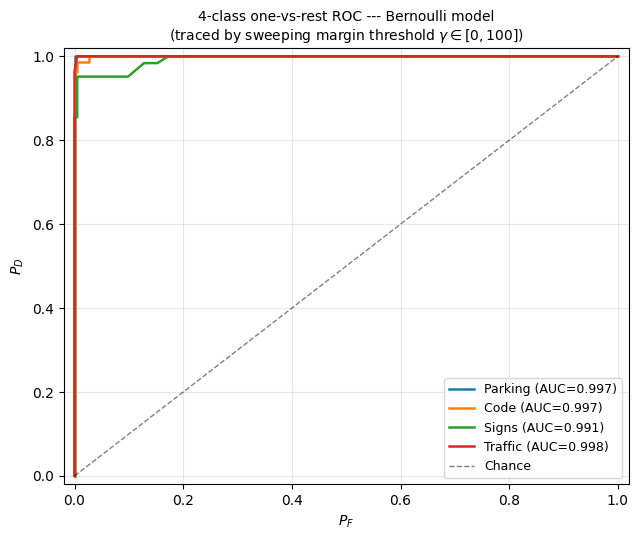

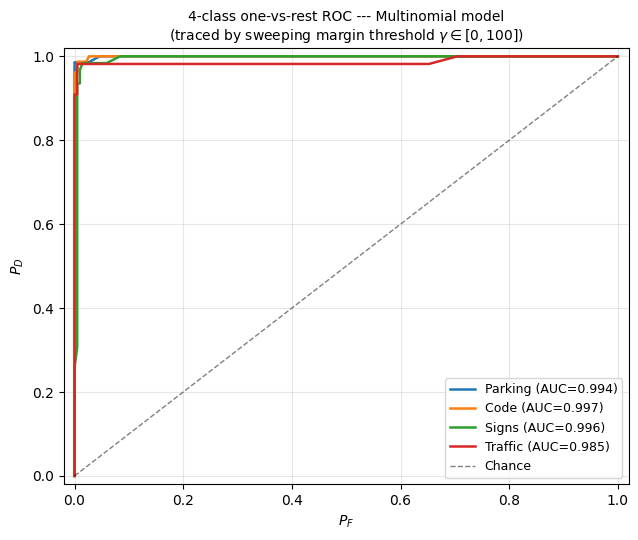

In [ ]:
for model in ["bernoulli", "multinomial"]:
    r = mc_results[model]
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    cmap = plt.cm.tab10
    for k, cls in enumerate(ALL_CLASSES):
        # margin score: log P(H_k|x) - max_{l!=k} log P(H_l|x)
        lp = r["log_post"]
        score = lp[:, k] - np.delete(lp, k, axis=1).max(axis=1)
        PFs, PDs, auc = roc_one_vs_rest(score, r["y_true"], cls, GAMMA_GRID_MULTICLASS)
        ax.plot(PFs, PDs, lw=1.8, color=cmap(k),
                label=f"{SHORT[k]} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label="Chance")
    ax.set_xlabel(r"$P_F$"); ax.set_ylabel(r"$P_D$")
    ax.set_title(f"4-class one-vs-rest ROC --- {model.capitalize()} model\n"
                 r"(traced by sweeping margin threshold $\gamma\in[0,100]$)",
                 fontsize=10)
    ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    plt.tight_layout()
    plt.savefig(f"{OUT_FIGS}/{TASK2_PREFIX}roc_multiclass_{model}.png", dpi=140)
    plt.show()

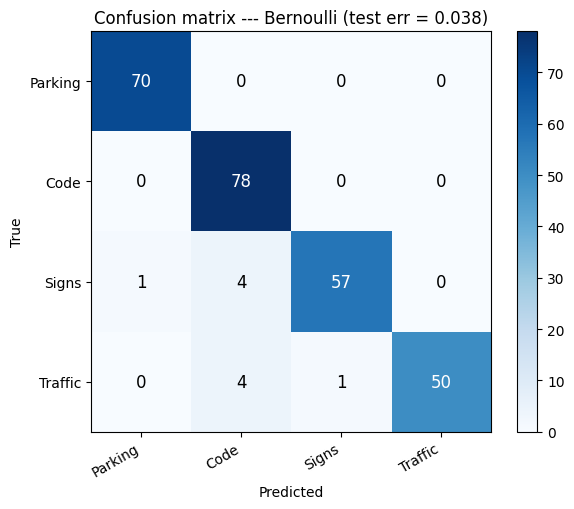

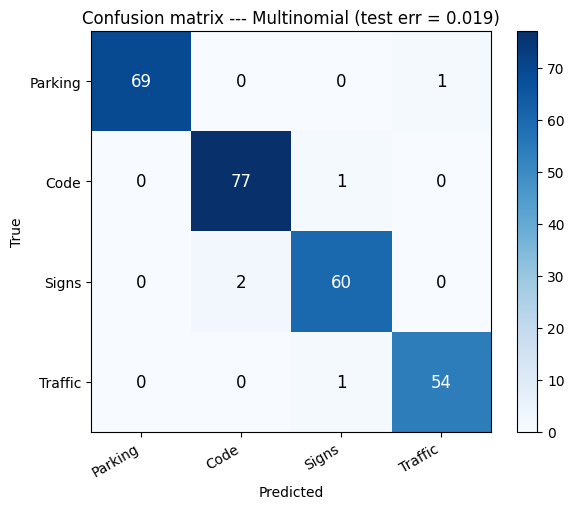


Figures -> ./figures/
Tables  -> ./tables/


In [ ]:
# -----------------------------------------------------------------
#  Confusion matrix heatmaps
# -----------------------------------------------------------------
for model in ["bernoulli", "multinomial"]:
    r = mc_results[model]
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    C = r["conf"]
    im = ax.imshow(C, cmap="Blues")
    ax.set_xticks(range(M)); ax.set_yticks(range(M))
    ax.set_xticklabels(SHORT, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(SHORT, fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion matrix --- {model.capitalize()} "
                 f"(test err = {r['err']:.3f})")
    for i in range(M):
        for j in range(M):
            ax.text(j, i, str(C[i, j]), ha="center", va="center",
                    color="white" if C[i, j] > C.max() / 2 else "black",
                    fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(f"{OUT_FIGS}/{TASK2_PREFIX}confusion_{model}.png", dpi=140)
    plt.show()

print(f"\nFigures -> ./{OUT_FIGS}/")
print(f"Tables  -> ./{OUT_TABS}/")